# 16 — Parameter Sensitivity Grid Sweep

**Maps to:** `report/Chapters/Task3.tex` §`T3:Sensitivity`.  
**Ticket:** TICKET-16.

Investigate how GA parameters influence performance on kroA100. Full
factorial grid over population size, crossover rate, mutation rate, and
selection method. 30 independent seeds per configuration for statistical
robustness.

All configurations use **PMX crossover** with **repair enabled** (random
insertion) — the baseline from the GA loop (notebook 10).

---
## Setup

In [1]:
%run ./15_experiment_runner.ipynb

Loaded kroA100: 100 cities


Best fitness : 84458.32
Known optimal: 21282
Gap          : 296.9%
Wall time    : 0.2s

Per-generation log (first 5 rows):
Saved: ../results/9e9a3301_seed0042.csv
Size : 11,657 bytes
Shape: (101, 16)
Cols : ['generation', 'best_fitness', 'mean_fitness', 'diversity', 'pop_size', 'n_generations', 'crossover_rate', 'mutation_rate', 'tournament_k', 'elitism_count', 'selection_method', 'crossover_method', 'mutation_method', 'repair_enabled', 'repair_strategy', 'seed']
Grid: 6 configurations
  976d5e2d | xover=pmx seed=1
  976d5e2d | xover=pmx seed=2
  976d5e2d | xover=pmx seed=3
  0fc01629 | xover=ox seed=1
  0fc01629 | xover=ox seed=2
  0fc01629 | xover=ox seed=3
Total: 6 | Completed: 6 | Pending: 0
Nothing to run — all results already exist.
Re-running the same grid (all should be skipped):
Total: 6 | Completed: 6 | Pending: 0
Nothing to run — all results already exist.


In [2]:
import matplotlib.pyplot as plt

FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

OPTIMAL = 21282

---
## Load Benchmark

In [3]:
coords, dist_matrix = load_tsp(Path("../data/TSP-dataset/kroA100.tsp"))
n_cities = dist_matrix.shape[0]
print(f"Loaded kroA100: {n_cities} cities")

Loaded kroA100: 100 cities


---
## Sweep Grid

Full factorial design:
- **Population size:** {50, 100, 200}
- **Crossover rate:** {0.7, 0.85, 0.95}
- **Mutation rate:** {0.01, 0.05, 0.1}
- **Selection method:** {tournament, roulette}

Fixed parameters: PMX crossover, swap mutation, repair enabled (random),
tournament $k=3$, elitism count 2, 500 generations.

In [4]:
N_SEEDS = 30
SEEDS = list(range(1, N_SEEDS + 1))

PARAM_GRID = {
    "pop_size": [50, 100, 200],
    "crossover_rate": [0.7, 0.85, 0.95],
    "mutation_rate": [0.01, 0.05, 0.1],
    "selection_method": ["tournament", "roulette"],
}

BASE = {
    "n_generations": 500,
    "tournament_k": 3,
    "elitism_count": 2,
    "crossover_method": "pmx",
    "mutation_method": "swap",
    "repair_enabled": True,
    "repair_strategy": "random",
}

configs = build_grid(PARAM_GRID, SEEDS, BASE)

n_configs = len(configs) // N_SEEDS
print(f"Unique configurations: {n_configs}")
print(f"Seeds per config: {N_SEEDS}")
print(f"Total runs: {len(configs)}")

Unique configurations: 54
Seeds per config: 30
Total runs: 1620


---
## Run Sweep

Execute all configurations with multiprocessing. Completed runs are
automatically skipped (resumability from notebook 15).

In [5]:
import os
n_workers = max(1, os.cpu_count() - 2)
print(f"Using {n_workers} workers")

run_grid(configs, dist_matrix, n_workers=n_workers)

Using 8 workers
Total: 1620 | Completed: 0 | Pending: 1620


  [1/1620] 6d91cd64_seed0001.csv  best=98824  (1s elapsed, ~2326s remaining)
  [2/1620] 6d91cd64_seed0002.csv  best=98087  (1s elapsed, ~1171s remaining)
  [3/1620] 6d91cd64_seed0003.csv  best=91772  (1s elapsed, ~784s remaining)
  [4/1620] 6d91cd64_seed0004.csv  best=99732  (1s elapsed, ~589s remaining)
  [5/1620] 6d91cd64_seed0005.csv  best=96085  (1s elapsed, ~472s remaining)
  [6/1620] 6d91cd64_seed0006.csv  best=102724  (1s elapsed, ~394s remaining)
  [7/1620] 6d91cd64_seed0007.csv  best=98845  (1s elapsed, ~339s remaining)
  [8/1620] 6d91cd64_seed0008.csv  best=100551  (1s elapsed, ~298s remaining)


  [9/1620] 6d91cd64_seed0009.csv  best=97293  (3s elapsed, ~480s remaining)
  [10/1620] 6d91cd64_seed0010.csv  best=98390  (3s elapsed, ~448s remaining)
  [11/1620] 6d91cd64_seed0011.csv  best=93647  (3s elapsed, ~407s remaining)
  [12/1620] 6d91cd64_seed0012.csv  best=95469  (3s elapsed, ~374s remaining)
  [13/1620] 6d91cd64_seed0013.csv  best=96386  (3s elapsed, ~347s remaining)
  [14/1620] 6d91cd64_seed0014.csv  best=94216  (3s elapsed, ~327s remaining)
  [15/1620] 6d91cd64_seed0015.csv  best=90397  (3s elapsed, ~305s remaining)
  [16/1620] 6d91cd64_seed0016.csv  best=95729  (3s elapsed, ~286s remaining)


  [17/1620] 6d91cd64_seed0017.csv  best=93933  (4s elapsed, ~378s remaining)
  [18/1620] 6d91cd64_seed0018.csv  best=100941  (4s elapsed, ~358s remaining)
  [19/1620] 6d91cd64_seed0019.csv  best=93787  (4s elapsed, ~351s remaining)
  [20/1620] 6d91cd64_seed0020.csv  best=91023  (4s elapsed, ~334s remaining)
  [21/1620] 6d91cd64_seed0021.csv  best=94827  (4s elapsed, ~318s remaining)
  [22/1620] 6d91cd64_seed0022.csv  best=108239  (4s elapsed, ~304s remaining)
  [23/1620] 6d91cd64_seed0023.csv  best=99601  (4s elapsed, ~292s remaining)


  [24/1620] 6d91cd64_seed0024.csv  best=100038  (4s elapsed, ~281s remaining)


...

  [1616/1620] 47257f3f_seed0026.csv  best=98325  (892s elapsed, ~2s remaining)


  [1617/1620] 47257f3f_seed0027.csv  best=109326  (894s elapsed, ~2s remaining)
  [1618/1620] 47257f3f_seed0028.csv  best=103571  (894s elapsed, ~1s remaining)


  [1619/1620] 47257f3f_seed0029.csv  best=113572  (895s elapsed, ~1s remaining)


  [1620/1620] 47257f3f_seed0030.csv  best=108195  (895s elapsed, ~0s remaining)

Done: 1620 runs in 895.5s


[PosixPath('../results/6d91cd64_seed0001.csv'),
 PosixPath('../results/6d91cd64_seed0002.csv'),
 PosixPath('../results/6d91cd64_seed0003.csv'),
 PosixPath('../results/6d91cd64_seed0004.csv'),
 PosixPath('../results/6d91cd64_seed0005.csv'),
 PosixPath('../results/6d91cd64_seed0006.csv'),
 PosixPath('../results/6d91cd64_seed0007.csv'),
 PosixPath('../results/6d91cd64_seed0008.csv'),
 PosixPath('../results/6d91cd64_seed0009.csv'),
 PosixPath('../results/6d91cd64_seed0010.csv'),
 PosixPath('../results/6d91cd64_seed0011.csv'),
 PosixPath('../results/6d91cd64_seed0012.csv'),
 PosixPath('../results/6d91cd64_seed0013.csv'),
 PosixPath('../results/6d91cd64_seed0014.csv'),
 PosixPath('../results/6d91cd64_seed0015.csv'),
 PosixPath('../results/6d91cd64_seed0016.csv'),
 PosixPath('../results/6d91cd64_seed0017.csv'),
 PosixPath('../results/6d91cd64_seed0018.csv'),
 PosixPath('../results/6d91cd64_seed0019.csv'),
 PosixPath('../results/6d91cd64_seed0020.csv'),
 PosixPath('../results/6d91cd64_seed0021

---
## Collect Results

Load all result CSVs and extract final-generation metrics.

In [6]:
rows = []
for c in configs:
    path = result_path(c)
    if not path.exists():
        continue
    df = pd.read_csv(path)
    final = df.iloc[-1]
    rows.append({
        "pop_size": c.pop_size,
        "crossover_rate": c.crossover_rate,
        "mutation_rate": c.mutation_rate,
        "selection_method": c.selection_method,
        "seed": c.seed,
        "best_fitness": final["best_fitness"],
        "mean_fitness": final["mean_fitness"],
        "diversity": final["diversity"],
        "config_hash": config_hash(c),
    })

results = pd.DataFrame(rows)
print(f"Collected {len(results)} results across {results['config_hash'].nunique()} configurations")

Collected 1620 results across 54 configurations


---
## Summary Statistics

Per-configuration summary: mean, std, min, max of best fitness across
30 seeds. Sorted by mean best fitness (ascending = better).

In [7]:
group_cols = ["pop_size", "crossover_rate", "mutation_rate", "selection_method"]

summary = results.groupby(group_cols)["best_fitness"].agg(
    ["count", "mean", "std", "min", "max"]
).round(2).reset_index()

summary["gap_%"] = ((summary["mean"] - OPTIMAL) / OPTIMAL * 100).round(1)
summary = summary.sort_values("mean")

print(f"Top 10 configurations (lowest mean best fitness):")
print("=" * 100)
print(summary.head(10).to_string(index=False))
print()
print(f"Bottom 5 configurations (highest mean best fitness):")
print("=" * 100)
print(summary.tail(5).to_string(index=False))

Top 10 configurations (lowest mean best fitness):
 pop_size  crossover_rate  mutation_rate selection_method  count     mean     std      min      max  gap_%
      200            0.95           0.10       tournament     30 47538.99 3454.59 37956.44 54334.91  123.4
      200            0.85           0.10       tournament     30 48648.87 3717.78 42369.61 55717.70  128.6
      200            0.70           0.10       tournament     30 49178.86 3341.92 42092.58 55007.96  131.1
      200            0.95           0.05       tournament     30 52959.29 3672.41 44638.18 63535.00  148.8
      200            0.85           0.05       tournament     30 53616.67 3309.78 47858.14 60074.61  151.9
      200            0.70           0.05       tournament     30 53738.44 3348.28 47080.57 62172.62  152.5
      100            0.85           0.10       tournament     30 54737.89 3853.24 47178.58 62916.54  157.2
      100            0.95           0.10       tournament     30 55142.31 3161.58 48308.62 611

---
## Best Configuration

Identify the single best configuration for use in downstream experiments
(TICKET-17 Phase 2, TICKET-19).

In [8]:
best_row = summary.iloc[0]
print("Best configuration:")
print(f"  pop_size         : {int(best_row['pop_size'])}")
print(f"  crossover_rate   : {best_row['crossover_rate']}")
print(f"  mutation_rate    : {best_row['mutation_rate']}")
print(f"  selection_method : {best_row['selection_method']}")
print(f"  mean best fitness: {best_row['mean']:.2f}")
print(f"  std              : {best_row['std']:.2f}")
print(f"  gap to optimal   : {best_row['gap_%']:.1f}%")

Best configuration:
  pop_size         : 200
  crossover_rate   : 0.95
  mutation_rate    : 0.1
  selection_method : tournament
  mean best fitness: 47538.99
  std              : 3454.59
  gap to optimal   : 123.4%


---
## Parameter Sensitivity Analysis

### Effect of Population Size

Marginal effect of population size, averaging over all other parameters.

Saved: ../results/figures/sweep_pop_size.pdf


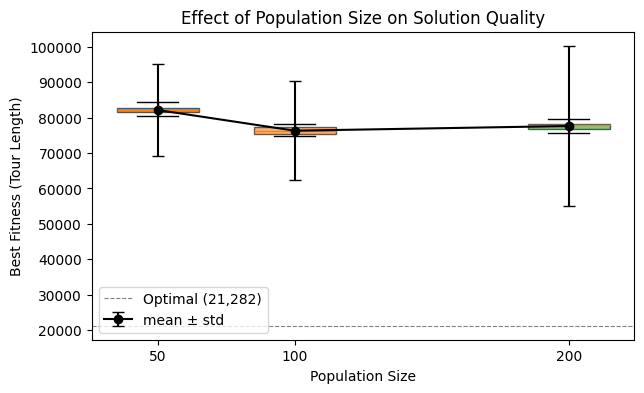

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))

for ps in sorted(results["pop_size"].unique()):
    subset = results[results["pop_size"] == ps]
    agg = subset.groupby("seed")["best_fitness"].mean().values
    ax.boxplot([subset.groupby("seed")["best_fitness"].mean().values],
               positions=[ps], widths=30, patch_artist=True,
               boxprops=dict(facecolor=f"C{sorted(results['pop_size'].unique()).index(ps)}", alpha=0.6))

pop_means = results.groupby("pop_size")["best_fitness"].agg(["mean", "std"]).reset_index()
ax.errorbar(pop_means["pop_size"], pop_means["mean"], yerr=pop_means["std"],
            fmt="o-", color="black", capsize=4, label="mean ± std")

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8, label=f"Optimal ({OPTIMAL:,})")
ax.set_xlabel("Population Size")
ax.set_ylabel("Best Fitness (Tour Length)")
ax.set_title("Effect of Population Size on Solution Quality")
ax.set_xticks(sorted(results["pop_size"].unique()))
ax.legend()

path = FIGURES_DIR / "sweep_pop_size.pdf"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

### Effect of Crossover Rate

Saved: ../results/figures/sweep_crossover_rate.pdf


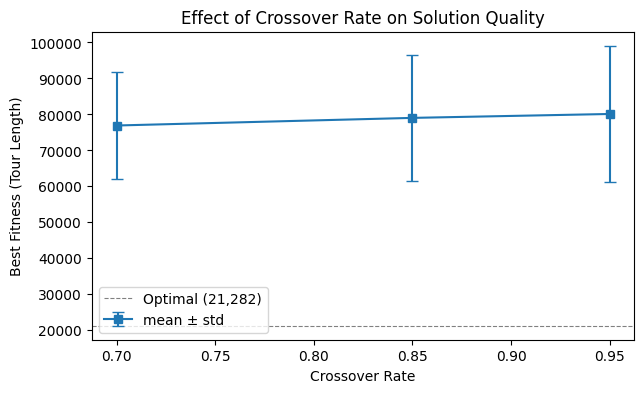

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))

xr_means = results.groupby("crossover_rate")["best_fitness"].agg(["mean", "std"]).reset_index()
ax.errorbar(xr_means["crossover_rate"], xr_means["mean"], yerr=xr_means["std"],
            fmt="s-", color="C0", capsize=4, label="mean ± std")

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8, label=f"Optimal ({OPTIMAL:,})")
ax.set_xlabel("Crossover Rate")
ax.set_ylabel("Best Fitness (Tour Length)")
ax.set_title("Effect of Crossover Rate on Solution Quality")
ax.legend()

path = FIGURES_DIR / "sweep_crossover_rate.pdf"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

### Effect of Mutation Rate

Saved: ../results/figures/sweep_mutation_rate.pdf


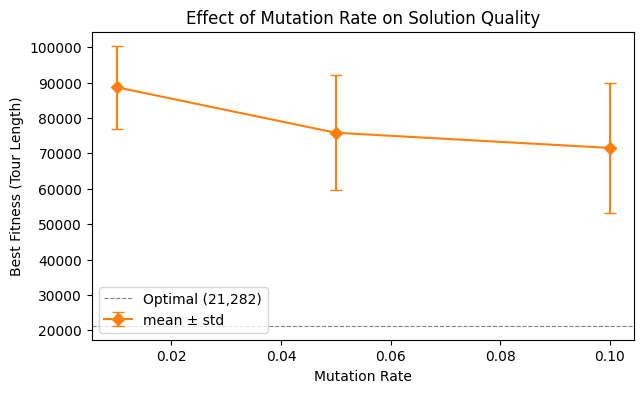

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))

mr_means = results.groupby("mutation_rate")["best_fitness"].agg(["mean", "std"]).reset_index()
ax.errorbar(mr_means["mutation_rate"], mr_means["mean"], yerr=mr_means["std"],
            fmt="D-", color="C1", capsize=4, label="mean ± std")

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8, label=f"Optimal ({OPTIMAL:,})")
ax.set_xlabel("Mutation Rate")
ax.set_ylabel("Best Fitness (Tour Length)")
ax.set_title("Effect of Mutation Rate on Solution Quality")
ax.legend()

path = FIGURES_DIR / "sweep_mutation_rate.pdf"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

### Effect of Selection Method

Saved: ../results/figures/sweep_selection_method.pdf


/var/folders/hy/13v77krx6dlfh5np6c_b8mdc0000gq/T/ipykernel_19245/2630557257.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(sel_data, labels=sel_labels, patch_artist=True, widths=0.5)


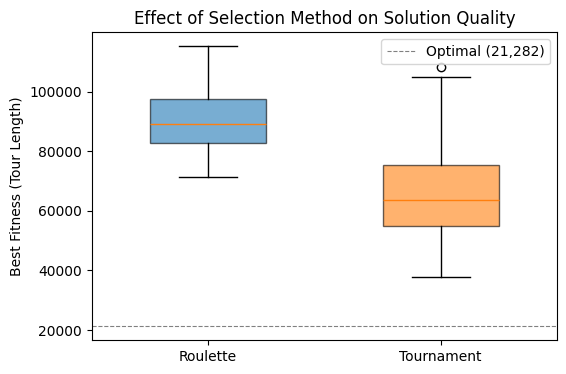

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))

sel_data = []
sel_labels = []
for method in sorted(results["selection_method"].unique()):
    subset = results[results["selection_method"] == method]["best_fitness"]
    sel_data.append(subset.values)
    sel_labels.append(method.capitalize())

bp = ax.boxplot(sel_data, labels=sel_labels, patch_artist=True, widths=0.5)
colors = ["C0", "C1"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8, label=f"Optimal ({OPTIMAL:,})")
ax.set_ylabel("Best Fitness (Tour Length)")
ax.set_title("Effect of Selection Method on Solution Quality")
ax.legend()

path = FIGURES_DIR / "sweep_selection_method.pdf"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

---
## Interaction: Population Size × Mutation Rate

Heatmap of mean best fitness for the two most impactful parameters,
averaged over crossover rate and selection method.

Saved: ../results/figures/sweep_heatmap_pop_mut.pdf


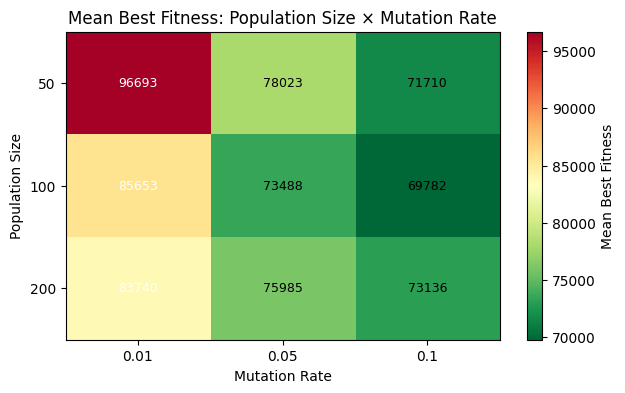

In [13]:
pivot = results.groupby(["pop_size", "mutation_rate"])["best_fitness"].mean().unstack()

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{v}" for v in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{v}" for v in pivot.index])
ax.set_xlabel("Mutation Rate")
ax.set_ylabel("Population Size")
ax.set_title("Mean Best Fitness: Population Size × Mutation Rate")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=9,
                color="white" if val > pivot.values.mean() else "black")

fig.colorbar(im, ax=ax, label="Mean Best Fitness")

path = FIGURES_DIR / "sweep_heatmap_pop_mut.pdf"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

---
## Export Sweep CSV

Save the full sweep results and per-configuration summary for downstream
notebooks.

In [14]:
sweep_path = Path("../results/sweep.csv")
results.to_csv(sweep_path, index=False)
print(f"Saved: {sweep_path} ({len(results)} rows)")

summary_path = Path("../results/sweep_summary.csv")
summary.to_csv(summary_path, index=False)
print(f"Saved: {summary_path} ({len(summary)} rows)")

Saved: ../results/sweep.csv (1620 rows)
Saved: ../results/sweep_summary.csv (54 rows)


---
## Runtime Summary

In [15]:
import glob

csv_files = glob.glob(str(RESULTS_DIR / "*.csv"))
csv_files = [f for f in csv_files if "sweep" not in f and "compare" not in f]

total_size = sum(Path(f).stat().st_size for f in csv_files)
print(f"Total result CSVs: {len(csv_files)}")
print(f"Total disk usage: {total_size / 1024 / 1024:.1f} MB")

Total result CSVs: 1687
Total disk usage: 91.2 MB


---
## Summary

This notebook runs a full factorial parameter sweep on kroA100:

- **Grid:** 3 pop sizes × 3 crossover rates × 3 mutation rates × 2 selection methods = 54 configurations
- **Seeds:** 30 independent runs per configuration = 1,620 total runs
- **Fixed:** PMX crossover, swap mutation, repair enabled (random), 500 generations

Outputs:
- `results/sweep.csv` — per-run results (1,620 rows)
- `results/sweep_summary.csv` — per-config summary statistics (54 rows)
- `results/figures/sweep_*.pdf` — sensitivity plots (pop size, crossover rate, mutation rate, selection method, heatmap)

The best configuration is identified for use in TICKET-17 Phase 2
(comparative experiment with the penalty function arm).